In [1]:
import numpy as np
import pandas as pd
import multiprocessing as mp
from inspect import signature
from matplotlib import pyplot as plt
from dacbench.logger import Logger, log2dataframe, load_logs
import seaborn as sns
import glob
from plotting import plot_performance_over_time, plot_final_performance_comparison, plot_improvement_probability, plot_configuration_footprint, plot_hp_importance, plot_deepcave
#from plotting import plot_performance_over_time, plot_final_performance_comparison, plot_improvement_probability, plot_configuration_footprint, plot_hp_importance, plot_deepcave

/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/dacbench/envs/__init__.py:35: UserWarning: CMA-ES Benchmark not installed. If you want to use this benchmark, please follow the installation guide.
  warnings.warn(  # noqa: B028
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/dacbench/benchmarks/__init__.py:26: UserWarning: CMA-ES Benchmark not installed. If you want to use this benchmark, please follow the installation guide.
  warnings.warn(  # noqa: B028


DACBench Gym registration failed - make sure you have all dependencies installed and their instance sets in the right path!


In [2]:
def toDataFrame(glob_path, col_name, col_index, method=None, dataset=None):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]
    
    df = pd.DataFrame([s[col_name][col_index] for s in d]).transpose()
    df['epoch'] = df.index + 1
    df = df.melt(id_vars=['epoch'])
    df.rename(columns={'variable': 'seed'}, inplace=True)
    
    if method:
        df['method'] = method

    if dataset:
        df['dataset'] = dataset

    return df

def toChunkedDataFrame(glob_path, col_name, col_index, chunk_size):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]

    df = pd.DataFrame([s[col_name][col_index] for s in d]).transpose()

    result_df = pd.DataFrame()
    for col in df.columns:
        reshaped_data = df[col].values.reshape(-1, chunk_size)
        result_df[col] = reshaped_data.mean(axis=1)

    result_df.reset_index()

    result_df['epoch'] = result_df.index + 1
    result_df = result_df.melt(id_vars=['epoch'])

    return result_df


sns.set(rc={"figure.dpi":300, 'savefig.dpi':300})
sns.set_style('whitegrid')
palette = sns.color_palette("colorblind")
palette = sns.color_palette([palette[0], palette[2], palette[1], palette[3], palette[4], palette[5]])
sns.set_palette(palette)

In [5]:
cocob_tl = toDataFrame('../results_cluster/results/COCOB_libsvm/aloi/*/CustomTrackingWrapper.jsonl', 'training_losses', 3, method='COCOB', dataset='aloi')
print(cocob_tl)

     epoch seed     value method dataset
0        1    0  6.129519  COCOB    aloi
1        2    0  6.047678  COCOB    aloi
2        3    0  6.070164  COCOB    aloi
3        4    0  6.038782  COCOB    aloi
4        5    0  6.000521  COCOB    aloi
..     ...  ...       ...    ...     ...
995     96    9  6.009200  COCOB    aloi
996     97    9  5.962801  COCOB    aloi
997     98    9  5.959416  COCOB    aloi
998     99    9  5.944421  COCOB    aloi
999    100    9  5.940288  COCOB    aloi

[1000 rows x 5 columns]


In [12]:
datasets = ['aloi', 'dna', 'iris', 'letter', 'pendigits', 'sensorless', 'vehicle', 'vowel', 'wine']

cocob_tl = pd.concat([toDataFrame('../results_cluster/results/COCOB_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'training_losses', 3, method='COCOB', dataset=dataset) for dataset in datasets], ignore_index=True)
dadaptation_tl = pd.concat([toDataFrame('../results_cluster/results/dadaptation_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'training_losses', 3, method='D-Adaptation', dataset=dataset) for dataset in datasets], ignore_index=True)
prodigy_tl = pd.concat([toDataFrame('../results_cluster/results/prodigy_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'training_losses', 3, method='Prodigy', dataset=dataset) for dataset in datasets], ignore_index=True)
# stormplus_tl = toDataFrame('./results_cluster/results/STORMplus_cifar10/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
adam_fixed_tl = pd.concat([toDataFrame('../results_cluster/results/Adam_fixed_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'training_losses', 3, method='Adam Fixed', dataset=dataset) for dataset in datasets], ignore_index=True)
# smac_fixed_tl = toDataFrame('../results_cluster/results/SMAC_fixed_cifar10/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
# smac_fixed_tl = smac_fixed_tl.loc[smac_fixed_tl['epoch'] <= 30]
# smac_policy_tl = toDataFrame('../results_cluster/results/smacpolicy_cifar10/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
# smac_policy_tl_new = toDataFrame('../results_cluster/results/smacpolicy_cifar10_new/*/CustomTrackingWrapper.jsonl', 'training_losses', 3)
dowg_tl = pd.concat([toDataFrame('../results_cluster/results/DoWG_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'training_losses', 3, method='DoWG', dataset=dataset) for dataset in datasets], ignore_index=True)
# cawr_tl = toChunkedDataFrame('../results_cluster/results/CAWR_cifar10/*/CustomTrackingWrapper.jsonl', 'training_losses', 3, 625)
# tuned_cawr_tl = toChunkedDataFrame('../results_cluster/results/tuned_CAWR_cifar10/*/CustomTrackingWrapper.jsonl', 'training_losses', 3, 625)
# sns.lineplot(data=stormplus_tl, x='epoch', y='value', label='STORMplus')
# p = sns.lineplot(data=adam_fixed_tl, x='epoch', y='value', label='Adam Fixed', linestyle='solid')
# sns.lineplot(data=cawr_tl, x='epoch', y='value', label='CAWR', linestyle="dashed")
# sns.lineplot(data=smac_fixed_tl, x='epoch', y='value', label='SMAC Fixed', linestyle='dashdot')
# # sns.lineplot(data=smac_policy_tl, x='epoch', y='value', label='SMAC Policy', linestyle='dotted')
# sns.lineplot(data=cocob_tl, x='epoch', y='value', label='COCOB', dashes=(4,2,1,2))
# sns.lineplot(data=dowg_tl, x='epoch', y='value', label='DoWG', dashes=(0.5, 0.5))
# sns.lineplot(data=tuned_cawr_tl, x='epoch', y='value', label='Tuned CAWR', linestyle="dashed")

# plt.xlabel('Epoch')
# plt.ylabel('Training Loss (Cross-Entropy)')
# plt.yscale('log')
# plt.yticks([0.25, 0.5, 1], ["0.25", "0.5", "1"])
# sns.move_legend(p, 'upper left', bbox_to_anchor=(0, -0.15), ncol=3)

# 'seed', 'epoch', 'method', 'training_loss' 'dataset'
print(cocob_tl)
df = pd.concat([cocob_tl, dadaptation_tl, prodigy_tl, adam_fixed_tl, dowg_tl], ignore_index=True)

TypeError: reduce() of empty iterable with no initial value

In [10]:

datasets = ['aloi', 'dna', 'iris', 'letter', 'pendigits', 'sensorless', 'vehicle', 'vowel', 'wine']

cocob_tl = pd.concat([toDataFrame('../results_cluster/results/COCOB_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'training_losses', 3, method='COCOB', dataset=dataset) for dataset in datasets], ignore_index=True)
dadaptation_tl = pd.concat([toDataFrame('../results_cluster/results/dadaptation_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'training_losses', 3, method='D-Adaptation', dataset=dataset) for dataset in datasets], ignore_index=True)
prodigy_tl = pd.concat([toDataFrame('../results_cluster/results/prodigy_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'training_losses', 3, method='Prodigy', dataset=dataset) for dataset in datasets], ignore_index=True)
adam_fixed_tl = pd.concat([toDataFrame('../results_cluster/results/Adam_fixed_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'training_losses', 3, method='Adam Fixed', dataset=dataset) for dataset in datasets], ignore_index=True)
dowg_tl = pd.concat([toDataFrame('../results_cluster/results/DoWG_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'training_losses', 3, method='DoWG', dataset=dataset) for dataset in datasets], ignore_index=True)


# 'seed', 'epoch', 'method', 'training_loss' 'dataset'
print(cocob_tl)
df = pd.concat([cocob_tl, dadaptation_tl, prodigy_tl, adam_fixed_tl, dowg_tl], ignore_index=True)

processes = 4
data_splits = []
for dim in df["dataset"].unique():
    data_splits.append(df[(df["dataset"] == dim)])
    
# print([df.iloc[0]['dataset'] for df in data_splits])
with mp.Pool(processes=processes) as pool:
    images = [pool.apply(plot_performance_over_time, kwds={"data":df, "x": "epoch", "y": "value", "aggregation": "mean", "hue": "method", "figsize": (6,4), "title": df.iloc[0]['dataset']}) for df in data_splits]

# Now we have to recompose the image
rows = len(df["dataset"].unique())
# columns = len(df["Benchmark"].unique())
fig = plt.figure(figsize=(6, 12))
for i, img in enumerate(images):
    fig.add_subplot(rows, 3, i+1)
    plt.imshow(img)
    plt.axis('off')
fig.tight_layout()
plt.show()

TypeError: reduce() of empty iterable with no initial value

      epoch seed     value method dataset
0         1    0  6.136685  COCOB    aloi
1         2    0  6.081927  COCOB    aloi
2         3    0  6.063240  COCOB    aloi
3         4    0  6.048708  COCOB    aloi
4         5    0  6.035073  COCOB    aloi
...     ...  ...       ...    ...     ...
8995     96    9  0.567656  COCOB    wine
8996     97    9  0.571958  COCOB    wine
8997     98    9  0.563864  COCOB    wine
8998     99    9  0.567237  COCOB    wine
8999    100    9  0.567105  COCOB    wine

[9000 rows x 5 columns]


/home/micha/Studium/BA_new/BA-Parameter-Free-DAC/ba_parameter_free_dac/plotting/plotting.py:205: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  ax = sns.lineplot(data=data, x=x, y=y, ax=ax, marker=marker, hue=hue, errorbar=errorbar, estimator=aggregation,palette=sns.color_palette('colorblind', as_cmap = True))
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/micha/Studium/BA_new/BA-Parameter-Free-DAC/ba_parameter_free_d

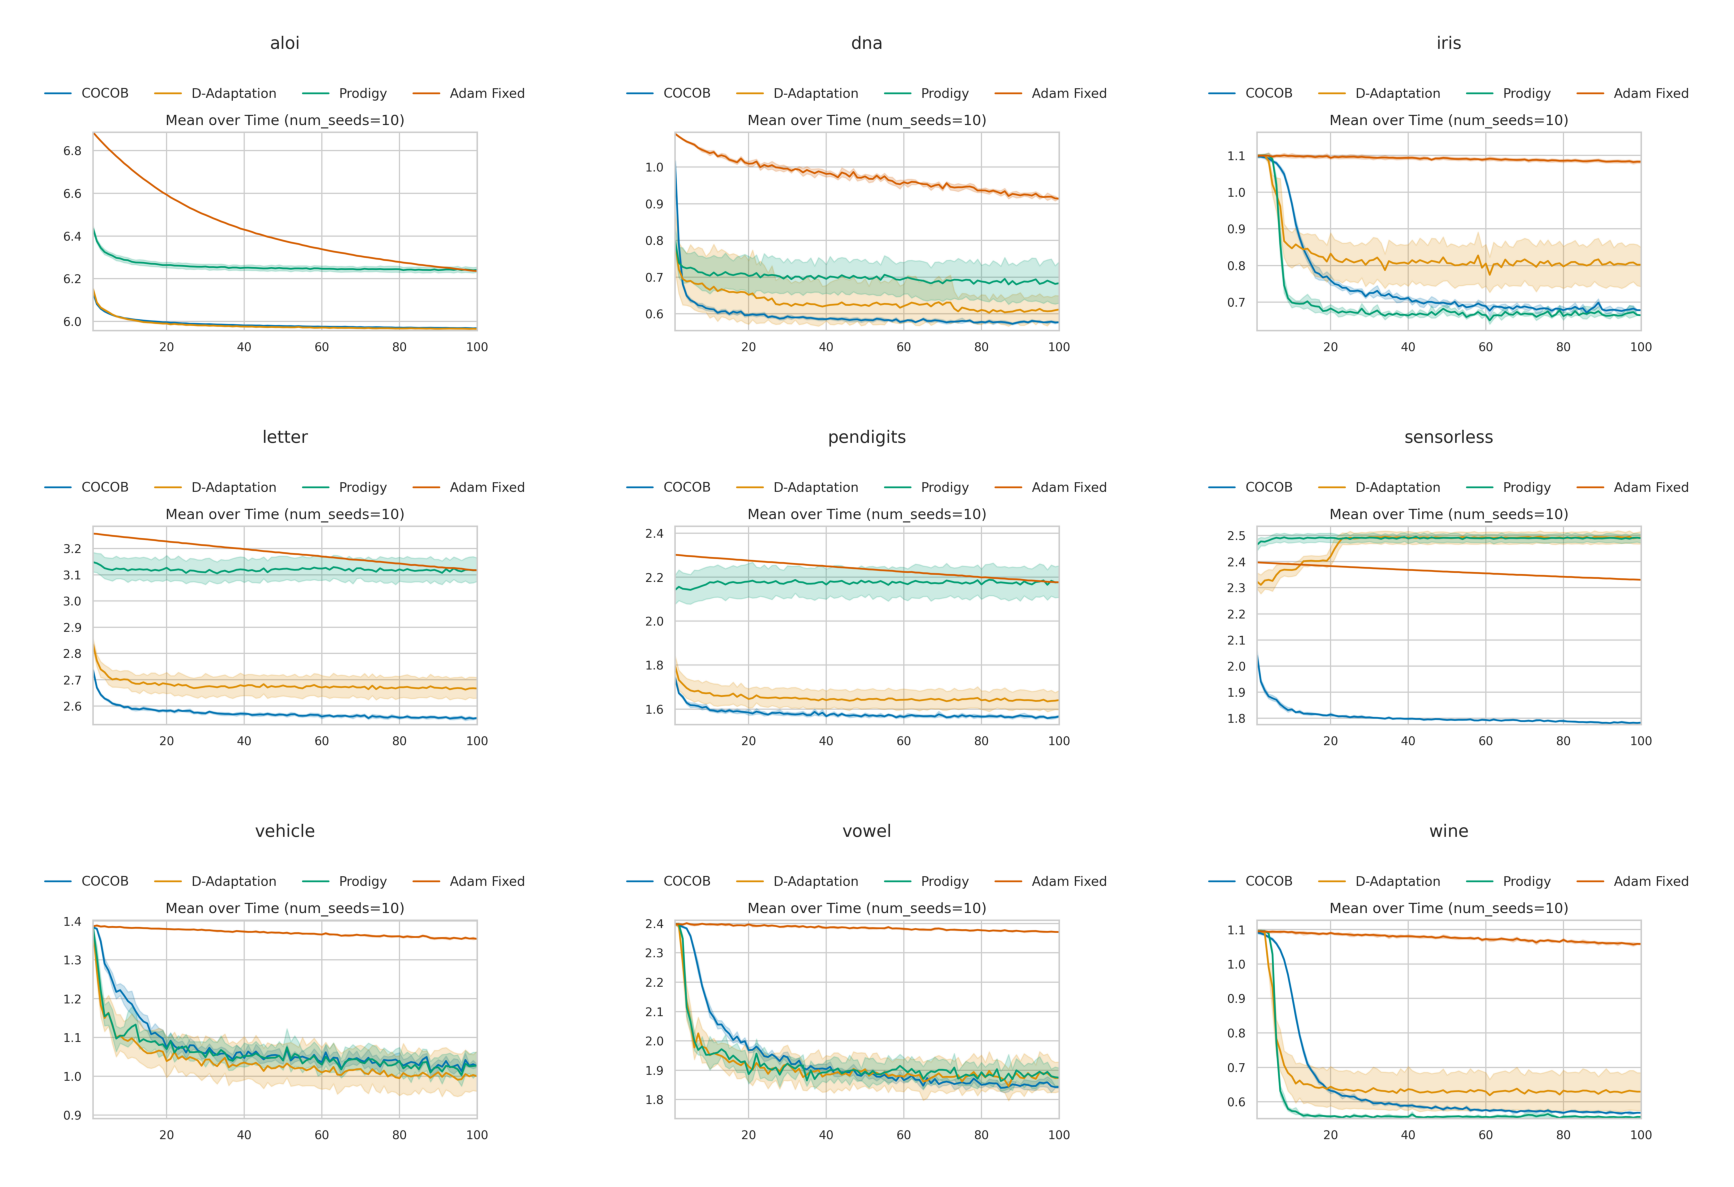

In [23]:

datasets = ['aloi', 'dna', 'iris', 'letter', 'pendigits', 'sensorless', 'vehicle', 'vowel', 'wine']

cocob_tl = pd.concat([toDataFrame('../results_cluster/results/COCOB_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5, method='COCOB', dataset=dataset) for dataset in datasets], ignore_index=True)
dadaptation_tl = pd.concat([toDataFrame('../results_cluster/results/dadaptation_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5, method='D-Adaptation', dataset=dataset) for dataset in datasets], ignore_index=True)
prodigy_tl = pd.concat([toDataFrame('../results_cluster/results/prodigy_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5, method='Prodigy', dataset=dataset) for dataset in datasets], ignore_index=True)
adam_fixed_tl = pd.concat([toDataFrame('../results_cluster/results/Adam_fixed_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5, method='Adam Fixed', dataset=dataset) for dataset in datasets], ignore_index=True)
dowg_tl = pd.concat([toDataFrame('../results_cluster/results/Dowg_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'validation_losses', 5, method='DoWG', dataset=dataset) for dataset in datasets], ignore_index=True)


# 'seed', 'epoch', 'method', 'training_loss' 'dataset'
print(cocob_tl)
df = pd.concat([cocob_tl, dadaptation_tl, prodigy_tl, adam_fixed_tl, dowg_tl], ignore_index=True)

processes = 4
data_splits = []
for dim in df["dataset"].unique():
    data_splits.append(df[(df["dataset"] == dim)])
    
# print([df.iloc[0]['dataset'] for df in data_splits])
with mp.Pool(processes=processes) as pool:
    images = [pool.apply(plot_performance_over_time, kwds={"data":df, "x": "epoch", "y": "value", "aggregation": "mean", "hue": "method", "figsize": (6,4), "title": df.iloc[0]['dataset']}) for df in data_splits]

# Now we have to recompose the image
rows = len(df["dataset"].unique())
# columns = len(df["Benchmark"].unique())
fig = plt.figure(figsize=(6, 12))
for i, img in enumerate(images):
    fig.add_subplot(rows, 3, i+1)
    plt.imshow(img)
    plt.axis('off')
fig.tight_layout()
plt.show()

      epoch seed     value method dataset
0         1    0  0.123521  COCOB    aloi
1         2    0  0.132674  COCOB    aloi
2         3    0  0.141272  COCOB    aloi
3         4    0  0.153199  COCOB    aloi
4         5    0  0.160133  COCOB    aloi
...     ...  ...       ...    ...     ...
8995     96    9  0.988125  COCOB    wine
8996     97    9  0.984375  COCOB    wine
8997     98    9  1.000000  COCOB    wine
8998     99    9  0.988125  COCOB    wine
8999    100    9  0.989583  COCOB    wine

[9000 rows x 5 columns]


/home/micha/Studium/BA_new/BA-Parameter-Free-DAC/ba_parameter_free_dac/plotting/plotting.py:205: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  ax = sns.lineplot(data=data, x=x, y=y, ax=ax, marker=marker, hue=hue, errorbar=errorbar, estimator=aggregation,palette=sns.color_palette('colorblind', as_cmap = True))
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/micha/Studium/BA_new/BA-Parameter-Free-DAC/ba_parameter_free_d

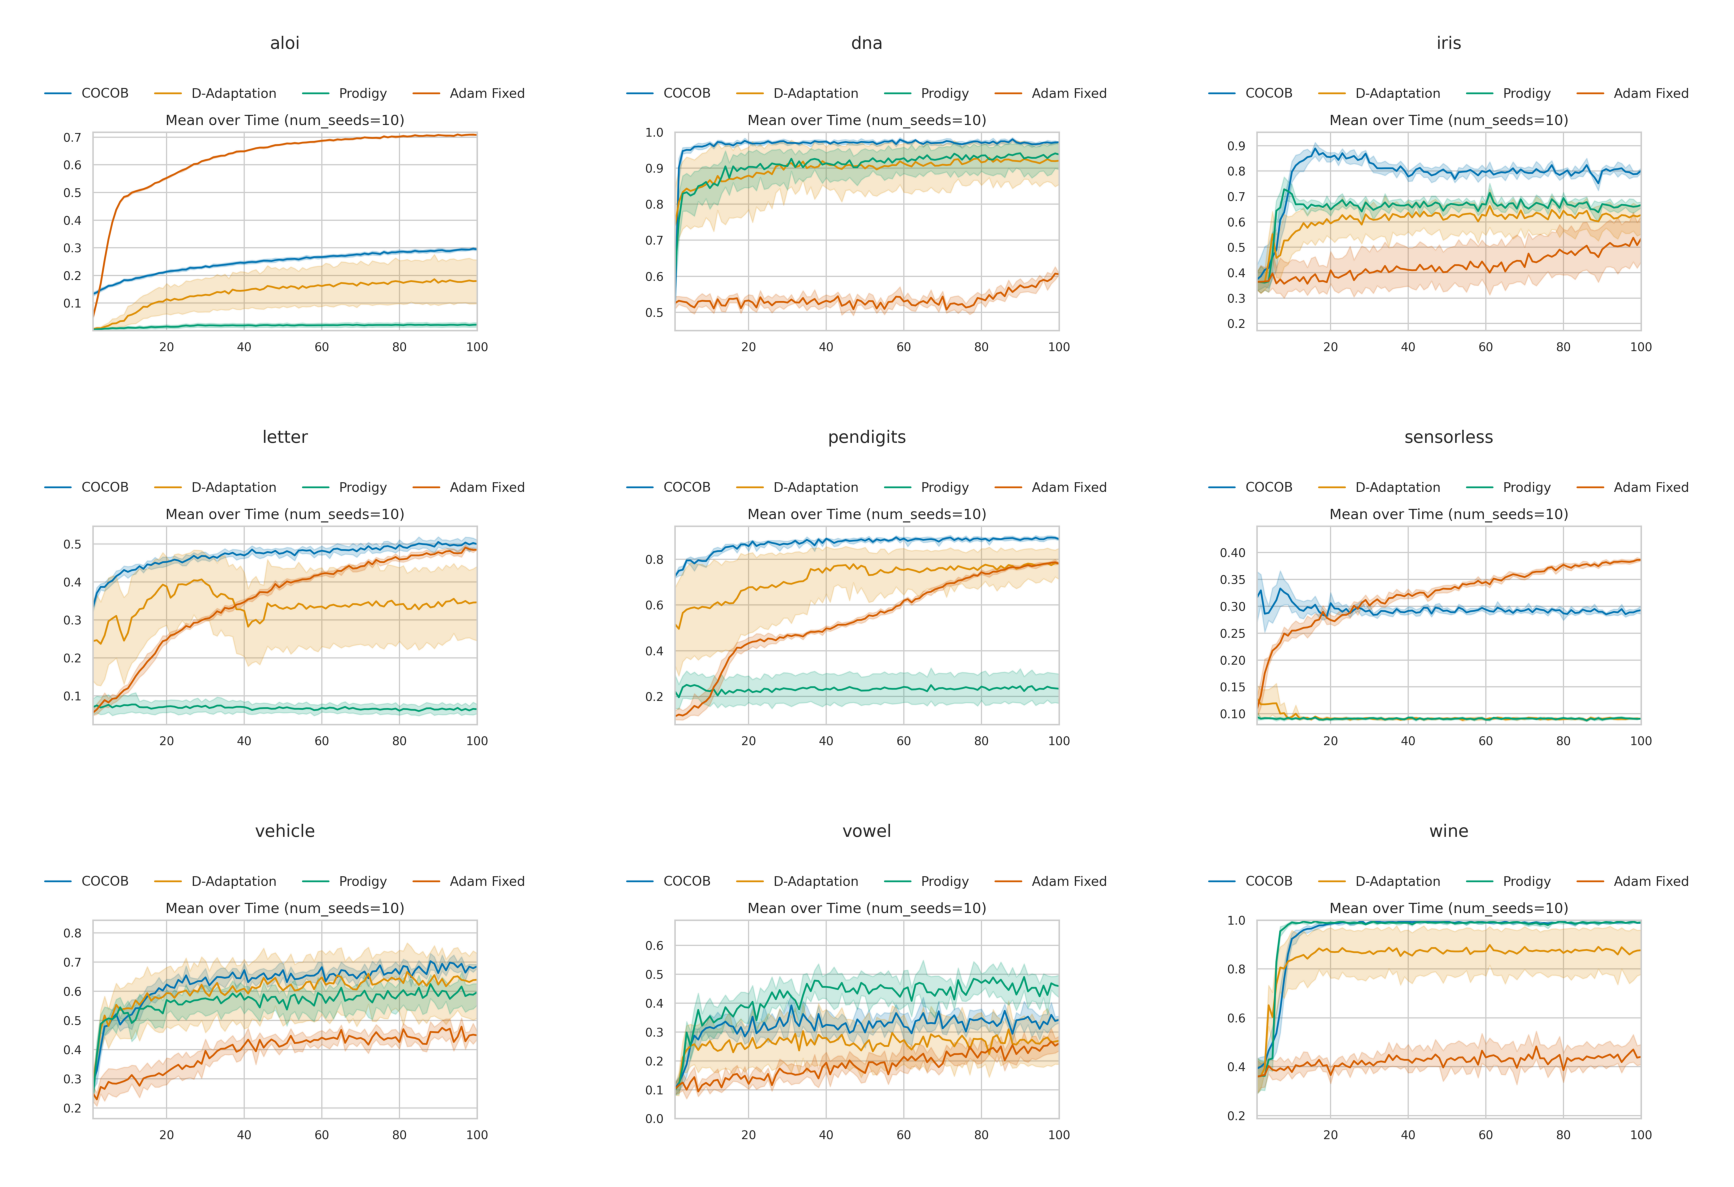

In [24]:

datasets = ['aloi', 'dna', 'iris', 'letter', 'pendigits', 'sensorless', 'vehicle', 'vowel', 'wine']

cocob_tl = pd.concat([toDataFrame('../results_cluster/results/COCOB_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6, method='COCOB', dataset=dataset) for dataset in datasets], ignore_index=True)
dadaptation_tl = pd.concat([toDataFrame('../results_cluster/results/dadaptation_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6, method='D-Adaptation', dataset=dataset) for dataset in datasets], ignore_index=True)
prodigy_tl = pd.concat([toDataFrame('../results_cluster/results/prodigy_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6, method='Prodigy', dataset=dataset) for dataset in datasets], ignore_index=True)
adam_fixed_tl = pd.concat([toDataFrame('../results_cluster/results/Adam_fixed_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6, method='Adam Fixed', dataset=dataset) for dataset in datasets], ignore_index=True)
dowg_tl = pd.concat([toDataFrame('../results_cluster/results/Dowg_libsvm/' + dataset + '/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6, method='DoWG', dataset=dataset) for dataset in datasets], ignore_index=True)


# 'seed', 'epoch', 'method', 'training_loss' 'dataset'
print(cocob_tl)
df = pd.concat([cocob_tl, dadaptation_tl, prodigy_tl, adam_fixed_tl, dowg_tl], ignore_index=True)

processes = 4
data_splits = []
for dim in df["dataset"].unique():
    data_splits.append(df[(df["dataset"] == dim)])
    
# print([df.iloc[0]['dataset'] for df in data_splits])
with mp.Pool(processes=processes) as pool:
    images = [pool.apply(plot_performance_over_time, kwds={"data":df, "x": "epoch", "y": "value", "aggregation": "mean", "hue": "method", "figsize": (6,4), "title": df.iloc[0]['dataset']}) for df in data_splits]

# Now we have to recompose the image
rows = len(df["dataset"].unique())
# columns = len(df["Benchmark"].unique())
fig = plt.figure(figsize=(6, 12))
for i, img in enumerate(images):
    fig.add_subplot(rows, 3, i+1)
    plt.imshow(img)
    plt.axis('off')
fig.tight_layout()
plt.show()

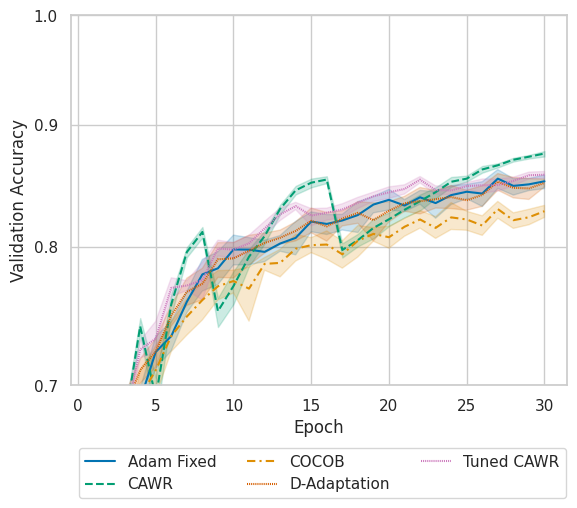

In [ ]:

cocob_va = toDataFrame('../results_cluster/results/COCOB_cifar10_30/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
adam_fixed_va = toDataFrame('../results_cluster/results/Adam_fixed_cifar10_30/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
smac_fixed_va = toDataFrame('../results_cluster/results/SMAC_fixed_cifar10_30/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
stormplus_va = toDataFrame('../results_cluster/results/STORMplus_cifar10/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
# smac_fixed_va = smac_fixed_va.loc[smac_fixed_va['epoch'] <= 30]
smac_policy_va = toDataFrame('../results_cluster/results/smacpolicy_cifar10/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
smac_policy_va_new = toDataFrame('../results_cluster/results/smacpolicy_cifar10_new/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
dowg_va = toDataFrame('../results_cluster/results/DoWG_cifar10_30/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
cawr_va = toDataFrame('../results_cluster/results/CAWR_cifar10/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
tuned_cawr_va = toDataFrame('../results_cluster/results/tuned_CAWR_cifar10_1/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
dadaptation_va = toDataFrame('../results_cluster/results/dadaptation_cifar10/*/CustomTrackingWrapper.jsonl', 'validation_accuracies', 6)
# cawr_va = cawr_va.loc[cawr_va['epoch'] <= 30]
# sns.lineplot(data=stormplus_va, x='epoch', y='value', label='STORM+')
p = sns.lineplot(data=adam_fixed_va, x='epoch', y='value', label='Adam Fixed', linestyle='solid')
sns.lineplot(data=cawr_va, x='epoch', y='value', label='CAWR', linestyle="dashed")
# sns.lineplot(data=smac_fixed_va, x='epoch', y='value', label='SMAC Fixed', linestyle='dashdot')
# sns.lineplot(data=smac_policy_va, x='epoch', y='value', label='SMAC Policy', linestyle='dotted')
sns.lineplot(data=cocob_va, x='epoch', y='value', label='COCOB', dashes=(4,2,1,2))
# sns.lineplot(data=dowg_va, x='epoch', y='value', label='DoWG', dashes=(0.5, 0.5))
sns.lineplot(data=dadaptation_va, x='epoch', y='value', label='D-Adaptation', dashes=(0.5, 0.5))
sns.lineplot(data=tuned_cawr_va, x='epoch', y='value', label='Tuned CAWR', dashes=(0.5, 0.5))

plt.title('CIFAR-10')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.yscale('log')
plt.ylim(0.7, 1)
plt.yticks([0.7, 0.8, 0.9, 1], ["0.7", "0.8", "0.9", "1.0"])
sns.move_legend(p, 'upper left', bbox_to_anchor=(0, -0.15), ncol=3)

Text(0, 0.5, 'Validation Accuracy')

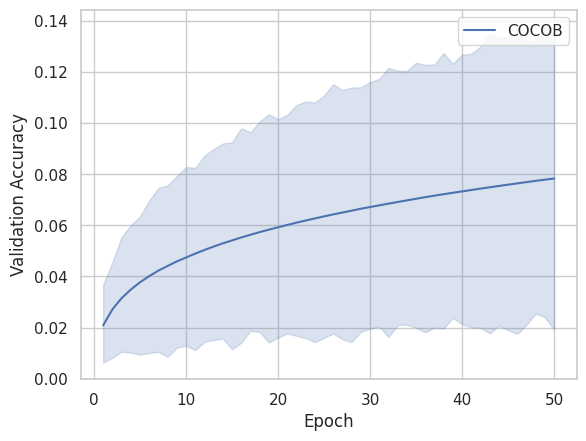

In [26]:

cocob_elr = toDataFrame('./results_cluster/results/COCOB_cifar10/*/CustomTrackingWrapper.jsonl', 'effective_lrs', 9)
sns.lineplot(data=cocob_elr, x='epoch', y='value', label='COCOB')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')